In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import HashingVectorizer

np.random.seed(42)

In [3]:
_vectorizer = HashingVectorizer(n_features=16, alternate_sign=False, norm='l2')

KEYWORDS = {
    'urgent': ['urgent', 'asap', 'immediately', 'rush'],
    'enterprise': ['enterprise', 'corporation', 'large company', 'fortune'],
    'startup': ['startup', 'seed', 'early-stage', 'small team'],
    'long_term': ['long-term', 'ongoing', 'retainer', 'monthly'],
    'complex': ['dashboard', 'machine learning', 'ai', 'integration', 'scalable', 'architecture'],
    'simple': ['simple', 'basic', 'small fix', 'quick', 'landing page'],
}

def extract_features(description: str) -> np.ndarray:
    text = description.lower()
    keyword_feats = [1.0 if any(w in text for w in words) else 0.0 for words in KEYWORDS.values()]
    length_feat = min(len(text.split()) / 100.0, 1.0)
    text_embedding = _vectorizer.transform([text]).toarray()[0]
    context = np.concatenate([keyword_feats, [length_feat], text_embedding, [1.0]])
    return context

CONTEXT_DIM = len(extract_features('test project description'))
print('Context dimension:', CONTEXT_DIM)

Context dimension: 24


In [4]:
PRICE_MULTIPLIERS = [0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 1.8, 2.0]
N_ARMS = len(PRICE_MULTIPLIERS)
print(f'{N_ARMS} arms:', PRICE_MULTIPLIERS)

8 arms: [0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 1.8, 2.0]


In [5]:
class LinUCB:
    def __init__(self, n_arms: int, context_dim: int, alpha: float = 1.0):
        self.n_arms = n_arms
        self.d = context_dim
        self.alpha = alpha
        self.A = [np.identity(self.d) for _ in range(n_arms)]
        self.b = [np.zeros(self.d) for _ in range(n_arms)]

    def select_arm(self, x: np.ndarray) -> int:
        p = np.zeros(self.n_arms)
        for a in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            p[a] = theta @ x + self.alpha * np.sqrt(x @ A_inv @ x)
        return int(np.argmax(p))

    def all_estimates(self, x: np.ndarray):
        means, ucbs = [], []
        for a in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            mean = theta @ x
            bonus = self.alpha * np.sqrt(x @ A_inv @ x)
            means.append(mean)
            ucbs.append(mean + bonus)
        return np.array(means), np.array(ucbs)

    def update(self, arm: int, x: np.ndarray, reward: float):
        self.A[arm] += np.outer(x, x)
        self.b[arm] += reward * x

    def save(self, path: str):
        np.savez(path, A=np.array(self.A), b=np.array(self.b), alpha=self.alpha)

    @classmethod
    def load(cls, path: str, n_arms: int, context_dim: int):
        data = np.load(path)
        obj = cls(n_arms, context_dim, alpha=float(data['alpha']))
        obj.A = [data['A'][i] for i in range(n_arms)]
        obj.b = [data['b'][i] for i in range(n_arms)]
        return obj

In [6]:
SAMPLE_DESCRIPTIONS = [
    'Build a React dashboard for an enterprise client, scalable architecture needed',
    'Quick landing page fix, simple task, urgent turnaround',
    'Ongoing retainer work for a startup, long-term engagement',
    'Simple bug fix on an existing website, small team, quick job',
    'Machine learning integration for a large corporation, complex system',
    'Basic WordPress landing page for a small business, asap',
]

BASE_PRICE = 500.0

def true_win_prob(description: str, multiplier: float) -> float:
    text = description.lower()
    sensitivity = 0.35
    if any(w in text for w in ['enterprise', 'complex', 'machine learning', 'corporation']):
        sensitivity = 0.6
    elif any(w in text for w in ['simple', 'basic', 'quick']):
        sensitivity = 0.2
    center = 1.0
    return 1 / (1 + np.exp((multiplier - center) / sensitivity))

def simulate_outcome(description: str, multiplier: float) -> bool:
    prob = true_win_prob(description, multiplier)
    return np.random.rand() < prob

In [7]:
bandit = LinUCB(n_arms=N_ARMS, context_dim=CONTEXT_DIM, alpha=0.8)

N_ROUNDS = 2000
reward_history = []
regret_history = []

for t in range(N_ROUNDS):
    desc = np.random.choice(SAMPLE_DESCRIPTIONS)
    x = extract_features(desc)

    arm = bandit.select_arm(x)
    multiplier = PRICE_MULTIPLIERS[arm]
    price = BASE_PRICE * multiplier

    won = simulate_outcome(desc, multiplier)
    reward = price if won else 0.0

    bandit.update(arm, x, reward / BASE_PRICE)

    best_expected = max(BASE_PRICE * m * true_win_prob(desc, m) for m in PRICE_MULTIPLIERS)
    regret = best_expected - reward

    reward_history.append(reward)
    regret_history.append(regret)

print('Training done.')
print('Average reward (last 200 rounds):', np.mean(reward_history[-200:]))
print('Average reward (first 200 rounds):', np.mean(reward_history[:200]))

Training done.
Average reward (last 200 rounds): 257.0
Average reward (first 200 rounds): 248.0


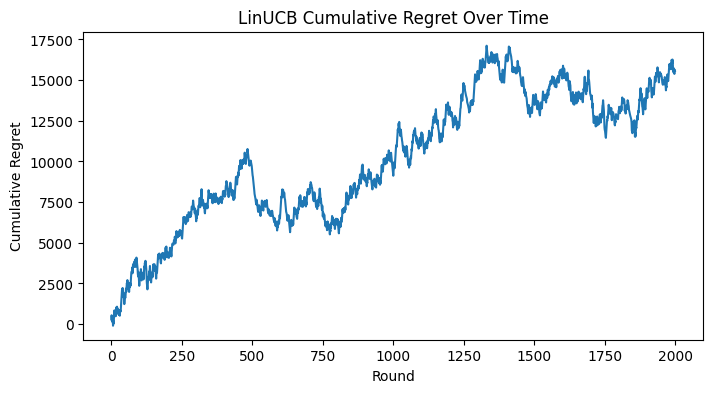

In [8]:
cumulative_regret = np.cumsum(regret_history)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_regret)
plt.xlabel('Round')
plt.ylabel('Cumulative Regret')
plt.title('LinUCB Cumulative Regret Over Time')
plt.show()

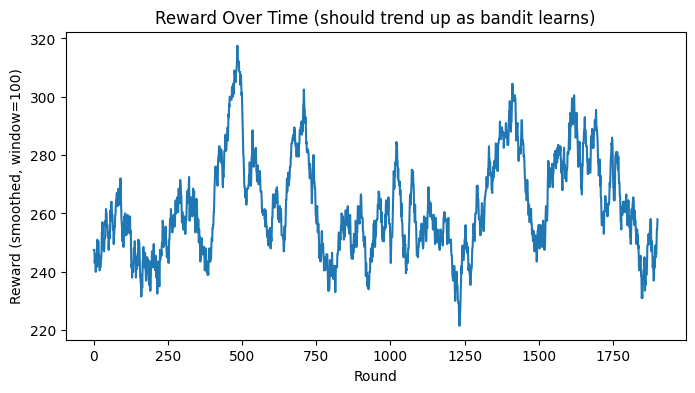

In [9]:
window = 100
smoothed_reward = np.convolve(reward_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(smoothed_reward)
plt.xlabel('Round')
plt.ylabel(f'Reward (smoothed, window={window})')
plt.title('Reward Over Time (should trend up as bandit learns)')
plt.show()

In [10]:
bandit.save('bandit_state.npz')
print('Saved to bandit_state.npz')

Saved to bandit_state.npz


In [ ]:

bandit_test = LinUCB(n_arms=N_ARMS, context_dim=CONTEXT_DIM, alpha=0.8)

N_TEST_ROUNDS = 2000
bandit_revenue = []
baseline_revenue = []

FLAT_MULTIPLIER = 1.0  

for t in range(N_TEST_ROUNDS):
    desc = np.random.choice(SAMPLE_DESCRIPTIONS)
    x = extract_features(desc)

    
    arm = bandit_test.select_arm(x)
    multiplier = PRICE_MULTIPLIERS[arm]
    won = simulate_outcome(desc, multiplier)
    reward = (BASE_PRICE * multiplier) if won else 0.0
    bandit_test.update(arm, x, reward / BASE_PRICE)
    bandit_revenue.append(reward)

    
    won_baseline = simulate_outcome(desc, FLAT_MULTIPLIER)
    baseline_revenue.append(BASE_PRICE * FLAT_MULTIPLIER if won_baseline else 0.0)

print("Total revenue — Bandit:", sum(bandit_revenue))
print("Total revenue — Flat baseline:", sum(baseline_revenue))
lift = (sum(bandit_revenue) - sum(baseline_revenue)) / sum(baseline_revenue) * 100
print(f"Revenue lift: {lift:.2f}%")

Total revenue — Bandit: 515650.0
Total revenue — Flat baseline: 496500.0
Revenue lift: 3.86%
